## Objective

After preprocessing and feature engineering, we can dive deeper into some baseline models and determine the best route for predicting the target variable. We will start out by splitting the test and training sets followed by fitting a baseline model and testing the residuals to see the performance of our model. We will also use Variable Inflaction Factors to help us further determine which variables will be useful going forward.

Note: you may need to restart the kernel to use updated packages.
Environment ready.
Total load functions: 25

load_combine
load_contracts
load_depth_charts
load_draft_picks
load_ff_opportunity
load_ff_playerids
load_ff_rankings
load_ffverse
load_ftn_charting
load_injuries
load_nextgen_stats
load_officials
load_participation
load_pbp
load_pfr_advstats
load_player_stats
load_players
load_rosters
load_rosters_weekly
load_schedules
load_snap_counts
load_stats
load_team_stats
load_teams
load_trades
Help on function load_player_stats in module nflreadpy.load_stats:

load_player_stats(
    seasons: int | list[int] | bool | None = None,
    summary_level: Literal['week', 'reg', 'post', 'reg+post'] = 'week'
) -> polars.dataframe.frame.DataFrame
    Load NFL player statistics.

    Args:
        seasons: Season(s) to load. If None, loads current season.
                If True, loads all available data.
                If int or list of ints, loads specified season(s).
        summary_level: Su

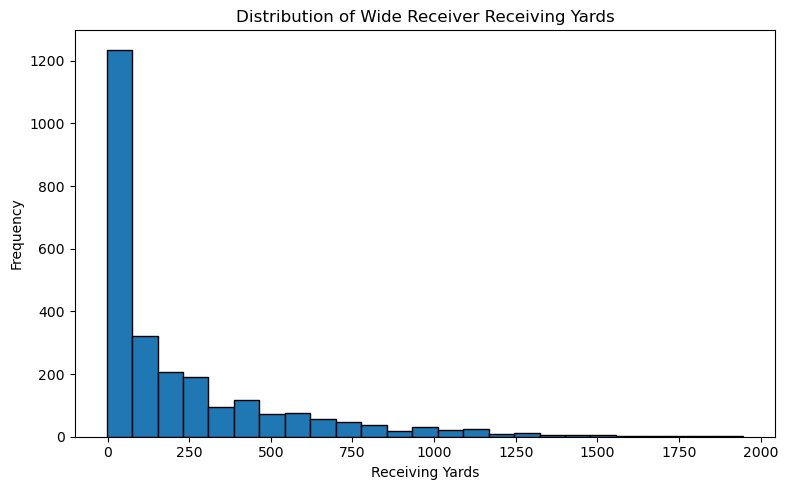

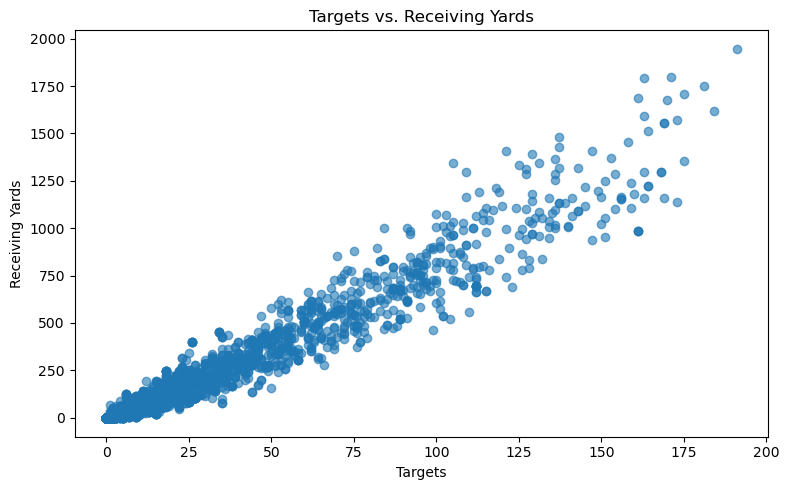

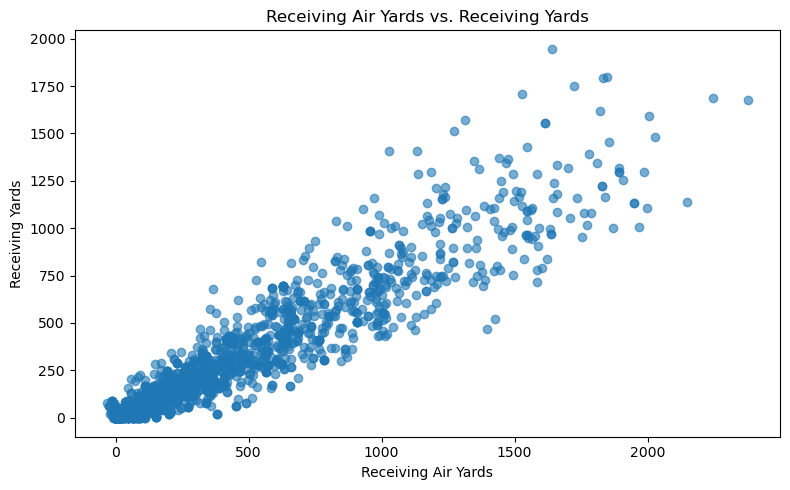

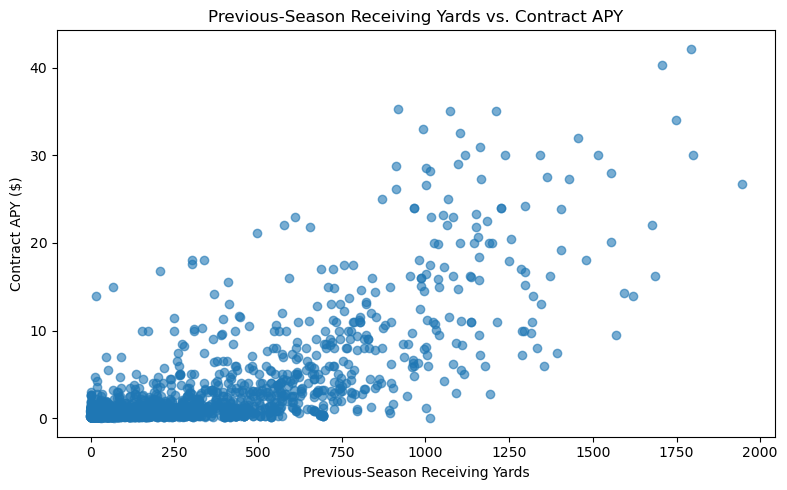

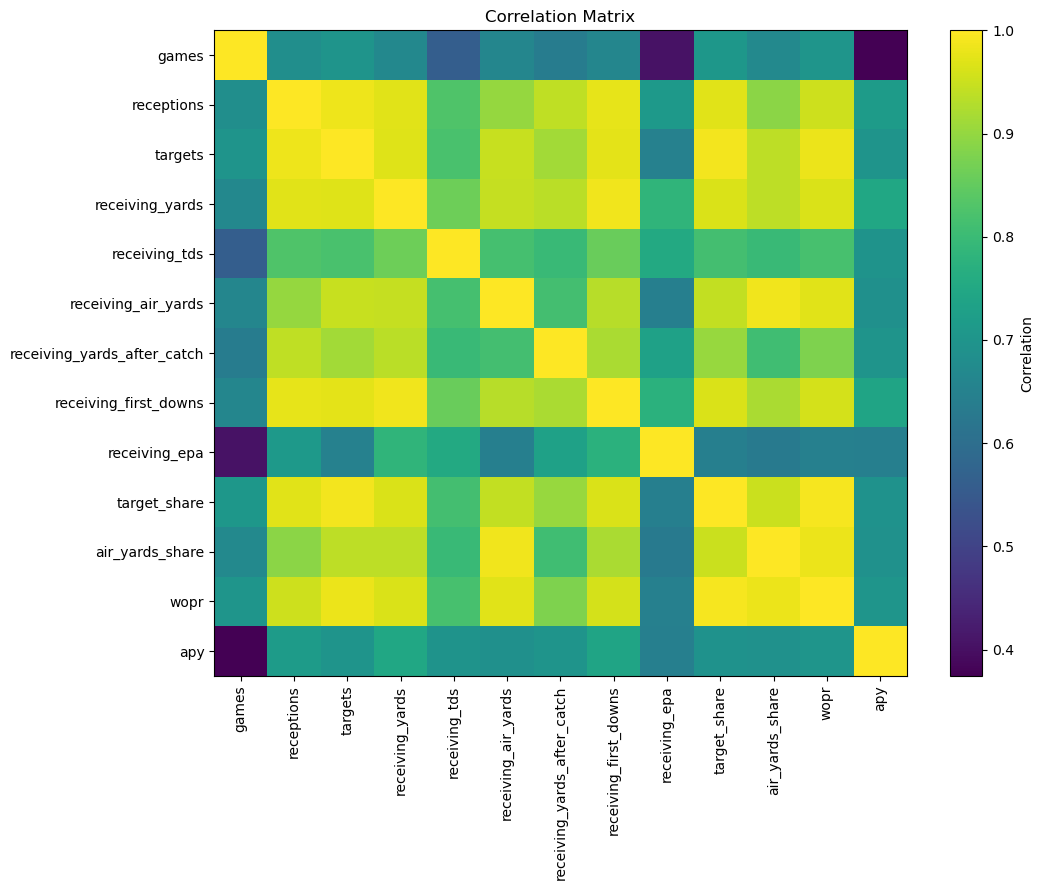

R-squared: 0.991
RMSE: 29.55
MAE: 18.55
Original dataset shape: (2595, 57)
Target variable: receiving_yards
Variables removed:
fantasy_points
fantasy_points_ppr
team
is_active
year_signed
years
value
apy
guaranteed
apy_cap_pct
inflated_value
inflated_apy
inflated_guaranteed
player
gsis_id
position
college
draft_team
recent_team
Variables removed because of missingness:
racr
receiving_epa
Candidate predictors:
games
targets_per_game
target_share
catch_rate
air_yards_per_target
air_yards_share
yac_per_reception
touchdowns_per_game
first_down_rate
years_of_experience


,games,targets_per_game,target_share,catch_rate,air_yards_per_target,air_yards_share,yac_per_reception,touchdowns_per_game,first_down_rate,years_of_experience,receiving_yards
games,1.000,0.490,0.705,0.312,0.113,0.669,0.257,0.363,0.273,0.534,0.667
targets_per_game,0.490,1.000,0.884,0.272,0.207,0.843,0.184,0.650,0.307,0.489,0.860
target_share,0.705,0.884,1.000,0.251,0.131,0.949,0.176,0.614,0.273,0.546,0.963
catch_rate,0.312,0.272,0.251,1.000,-0.002,0.192,0.417,0.237,0.639,0.180,0.267
air_yards_per_target,0.113,0.207,0.131,-0.002,1.000,0.252,0.061,0.157,0.252,0.081,0.144
air_yards_share,0.669,0.843,0.949,0.192,0.252,1.000,0.149,0.612,0.273,0.510,0.937
yac_per_reception,0.257,0.184,0.176,0.417,0.061,0.149,1.000,0.192,0.353,0.134,0.199
touchdowns_per_game,0.363,0.650,0.614,0.237,0.157,0.612,0.192,1.000,0.334,0.340,0.662
first_down_rate,0.273,0.307,0.273,0.639,0.252,0.273,0.353,0.334,1.000,0.156,0.315
years_of_experience,0.534,0.489,0.546,0.180,0.081,0.510,0.134,0.340,0.156,1.000,0.529


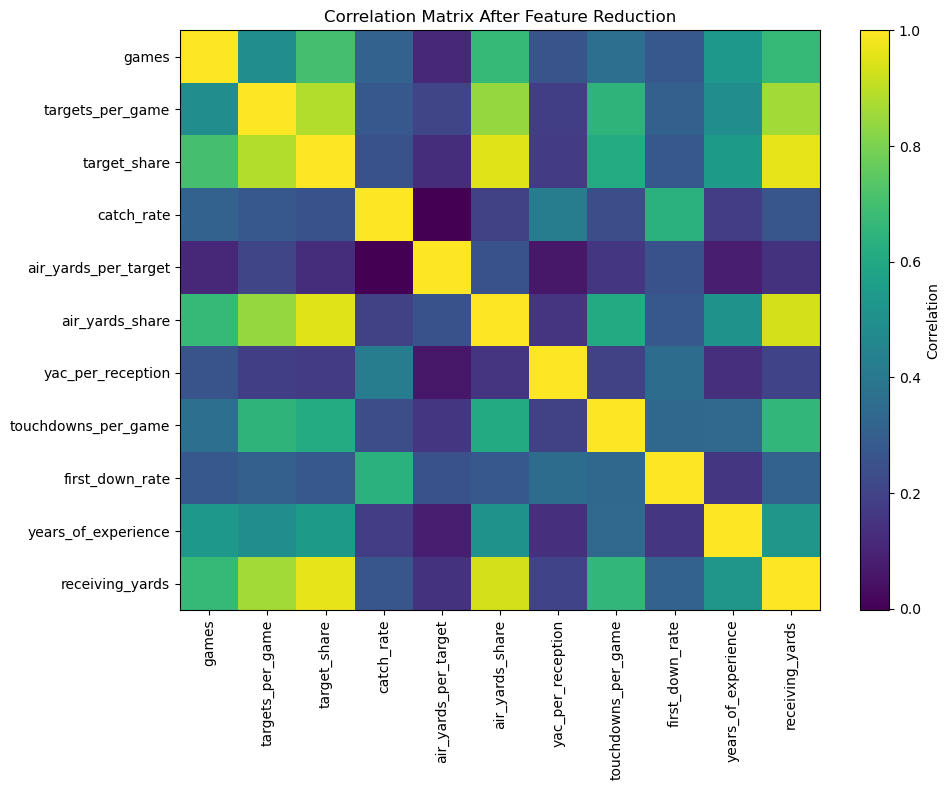

,Variable 1,Variable 2,Correlation
2,air_yards_share,target_share,0.949
0,target_share,targets_per_game,0.884
1,air_yards_share,targets_per_game,0.843


Modeling dataset shape: (2595, 11)
Training observations: 2076
Testing observations: 519


,Principal Component,Explained Variance,Cumulative Variance
0,1,0.4566,0.4566
1,2,0.1624,0.6190
2,3,0.1038,0.7229
3,4,0.0763,0.7991
4,5,0.0676,0.8667
5,6,0.0503,0.9170
6,7,0.0383,0.9553
7,8,0.0304,0.9856
8,9,0.0112,0.9968
9,10,0.0032,1.0000


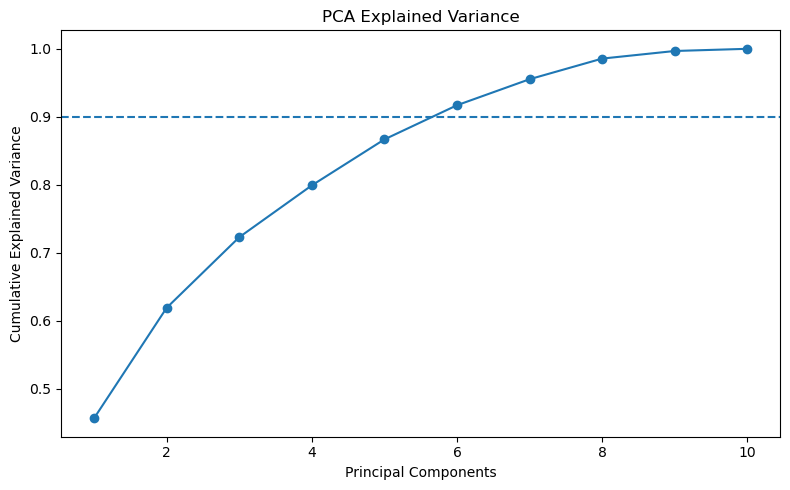

,PC1,PC2,PC3,PC4,PC5,PC6
games,0.355,-0.045,-0.218,-0.417,-0.122,-0.420
targets_per_game,0.410,-0.154,0.067,0.246,0.061,-0.012
target_share,0.433,-0.205,-0.078,0.088,0.011,-0.241
catch_rate,0.207,0.572,-0.199,0.110,-0.349,-0.045
air_yards_per_target,0.125,0.048,0.873,-0.388,-0.013,0.010
air_yards_share,0.424,-0.222,0.061,0.052,0.023,-0.250
yac_per_reception,0.161,0.478,-0.145,-0.289,0.784,0.002
touchdowns_per_game,0.334,-0.041,0.133,0.505,0.283,0.414
first_down_rate,0.229,0.542,0.191,0.154,-0.345,0.067
years_of_experience,0.302,-0.166,-0.248,-0.480,-0.212,0.725


,Variable,Coefficient,Absolute Coefficient
2,target_share,213.8467,213.8467
5,air_yards_share,70.5764,70.5764
7,touchdowns_per_game,26.3816,26.3816
8,first_down_rate,11.8197,11.8197
4,air_yards_per_target,-7.3535,7.3535
0,games,-7.2110,7.2110
1,targets_per_game,-6.6442,6.6442
6,yac_per_reception,4.6674,4.6674
9,years_of_experience,3.5159,3.5159
3,catch_rate,1.6251,1.6251


Variables selected by Lasso:
games
targets_per_game
target_share
catch_rate
air_yards_per_target
air_yards_share
yac_per_reception
touchdowns_per_game
first_down_rate
years_of_experience


In [18]:
from pathlib import Path

notebook_path = Path.home() / "Desktop" / "04_Preprocessing_Feature_Engineering.ipynb"

%run "$notebook_path"

In [19]:
# Baseline Modeling Imports

import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [20]:
# Fit baseline multiple linear regression model

baseline_model = LinearRegression()

baseline_model.fit(
    X_train_scaled,
    y_train
)

print("Baseline linear regression model fitted.")

Baseline linear regression model fitted.


In [21]:
# Generate predictions

y_train_pred = baseline_model.predict(
    X_train_scaled
)

y_test_pred = baseline_model.predict(
    X_test_scaled
)

In [22]:
# Evaluate baseline model

train_r2 = r2_score(
    y_train,
    y_train_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

train_rmse = (
    mean_squared_error(
        y_train,
        y_train_pred
    ) ** 0.5
)

test_rmse = (
    mean_squared_error(
        y_test,
        y_test_pred
    ) ** 0.5
)

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

print("Training R-squared:",
      round(train_r2, 3))

print("Testing R-squared:",
      round(test_r2, 3))

print("Training RMSE:",
      round(train_rmse, 2))

print("Testing RMSE:",
      round(test_rmse, 2))

print("Training MAE:",
      round(train_mae, 2))

print("Testing MAE:",
      round(test_mae, 2))

Training R-squared: 0.94
Testing R-squared: 0.95
Training RMSE: 74.28
Testing RMSE: 70.84
Training MAE: 45.59
Testing MAE: 43.81


In [23]:
# Baseline model performance table

baseline_results = pd.DataFrame({

    "Dataset": [
        "Training",
        "Testing"
    ],

    "R-squared": [
        train_r2,
        test_r2
    ],

    "RMSE": [
        train_rmse,
        test_rmse
    ],

    "MAE": [
        train_mae,
        test_mae
    ]

})

baseline_results.round(3)

,Dataset,R-squared,RMSE,MAE
0,Training,0.94,74.282,45.591
1,Testing,0.95,70.845,43.810


In [24]:
# Baseline model coefficients

baseline_coefficients = pd.DataFrame({

    "Variable":
        candidate_predictors,

    "Coefficient":
        baseline_model.coef_

})

baseline_coefficients[
    "Absolute Coefficient"
] = (
    baseline_coefficients[
        "Coefficient"
    ].abs()
)

baseline_coefficients = (
    baseline_coefficients
    .sort_values(
        "Absolute Coefficient",
        ascending=False
    )
)

baseline_coefficients.round(3)

,Variable,Coefficient,Absolute Coefficient
2,target_share,218.414,218.414
5,air_yards_share,71.197,71.197
7,touchdowns_per_game,26.847,26.847
8,first_down_rate,12.099,12.099
1,targets_per_game,-11.149,11.149
0,games,-9.815,9.815
4,air_yards_per_target,-7.361,7.361
6,yac_per_reception,5.052,5.052
9,years_of_experience,4.277,4.277
3,catch_rate,2.101,2.101


In [25]:
# Five-fold cross-validation

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=6311
)

cv_r2_scores = cross_val_score(
    LinearRegression(),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="r2"
)

cv_rmse_scores = (
    -cross_val_score(
        LinearRegression(),
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
) ** 0.5

print(
    "Cross-validation R-squared scores:",
    np.round(cv_r2_scores, 3)
)

print(
    "Mean CV R-squared:",
    round(cv_r2_scores.mean(), 3)
)

print(
    "Mean CV RMSE:",
    round(cv_rmse_scores.mean(), 2)
)

Cross-validation R-squared scores: [0.952 0.941 0.944 0.935 0.921]
Mean CV R-squared: 0.939
Mean CV RMSE: 74.84


In [26]:
# Cross-validation summary

cv_summary = pd.DataFrame({

    "Fold":
        range(1, 6),

    "R-squared":
        cv_r2_scores,

    "RMSE":
        cv_rmse_scores

})

cv_summary.round(3)

,Fold,R-squared,RMSE
0,1,0.952,66.605
1,2,0.941,74.022
2,3,0.944,71.323
3,4,0.935,74.932
4,5,0.921,87.316


In [27]:
# Calculate residuals

test_residuals = (
    y_test - y_test_pred
)

train_residuals = (
    y_train - y_train_pred
)

print(
    "Mean testing residual:",
    round(test_residuals.mean(), 3)
)

Mean testing residual: 1.556


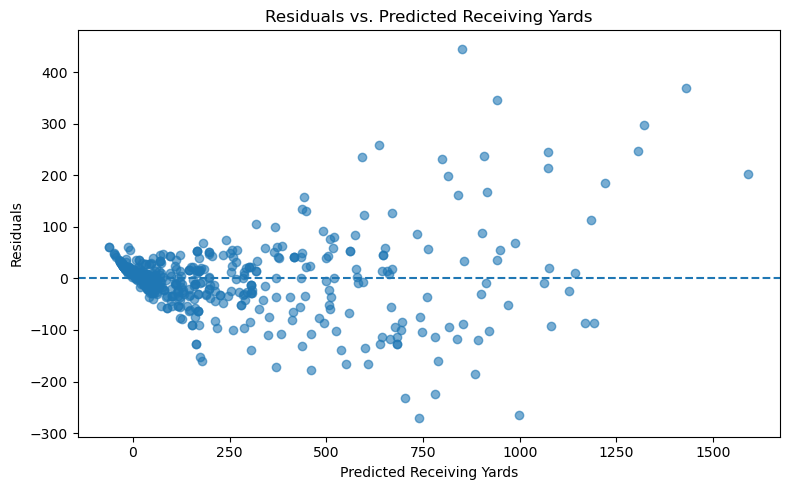

In [28]:
# Residuals versus predicted values

plt.figure(figsize=(8,5))

plt.scatter(
    y_test_pred,
    test_residuals,
    alpha=.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Receiving Yards"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Residuals vs. Predicted Receiving Yards"
)

plt.tight_layout()

plt.show()

We get an interesting shape here. A large group around 0 which is what we want to see, but as the predicted receiving yardage goes up, we see a much wider range of residuals

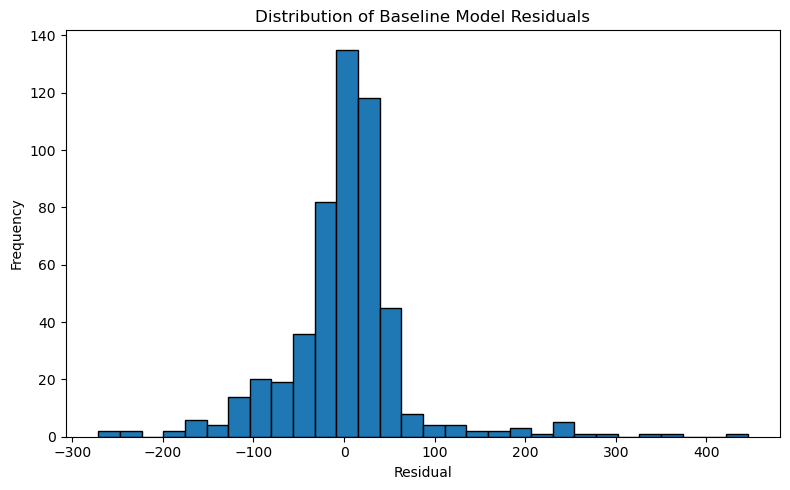

In [29]:
# Distribution of residuals

plt.figure(figsize=(8,5))

plt.hist(
    test_residuals,
    bins=30,
    edgecolor="black"
)

plt.xlabel(
    "Residual"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Baseline Model Residuals"
)

plt.tight_layout()

plt.show()

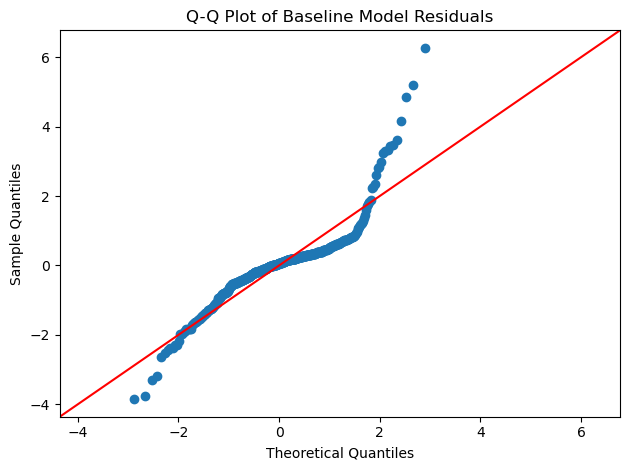

In [30]:
# Q-Q plot of residuals

sm.qqplot(
    test_residuals,
    line="45",
    fit=True
)

plt.title(
    "Q-Q Plot of Baseline Model Residuals"
)

plt.tight_layout()

plt.show()

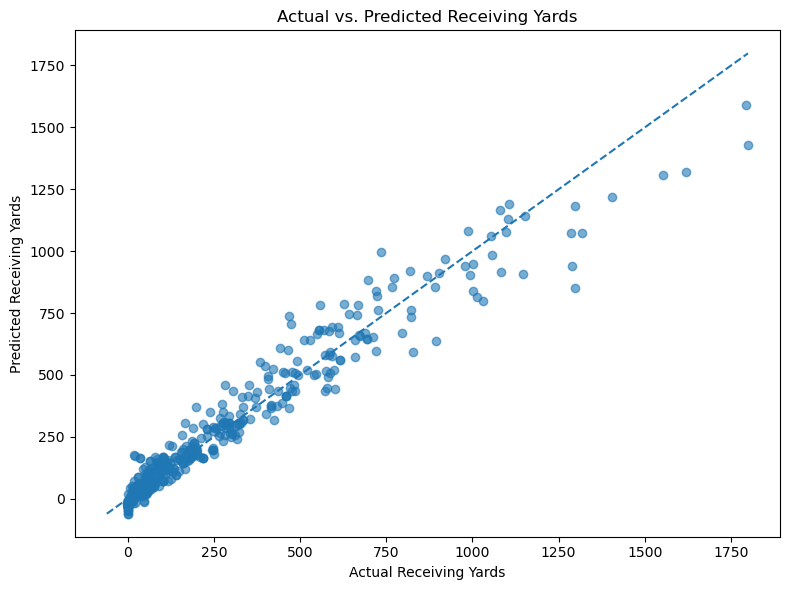

In [31]:
# Actual versus predicted receiving yards

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=.6
)

minimum = min(
    y_test.min(),
    y_test_pred.min()
)

maximum = max(
    y_test.max(),
    y_test_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual Receiving Yards"
)

plt.ylabel(
    "Predicted Receiving Yards"
)

plt.title(
    "Actual vs. Predicted Receiving Yards"
)

plt.tight_layout()

plt.show()

In [32]:
# Residual summary statistics

residual_summary = pd.DataFrame({

    "Mean":
        [test_residuals.mean()],

    "Standard Deviation":
        [test_residuals.std()],

    "Minimum":
        [test_residuals.min()],

    "Median":
        [test_residuals.median()],

    "Maximum":
        [test_residuals.max()]

})

residual_summary.round(2)

,Mean,Standard Deviation,Minimum,Median,Maximum
0,1.56,70.9,-271.3,5.64,445.51


In [33]:
# Variance Inflation Factor import

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

In [34]:
# Variance Inflation Factors

vif_results = pd.DataFrame()

vif_results["Variable"] = (
    candidate_predictors
)

vif_results["VIF"] = [

    variance_inflation_factor(
        X_train_scaled,
        i
    )

    for i in range(
        X_train_scaled.shape[1]
    )

]

vif_results = (
    vif_results
    .sort_values(
        "VIF",
        ascending=False
    )
)

vif_results.round(2)

,Variable,VIF
2,target_share,20.44
5,air_yards_share,12.55
1,targets_per_game,6.61
0,games,2.92
3,catch_rate,2.01
8,first_down_rate,1.99
7,touchdowns_per_game,1.83
9,years_of_experience,1.59
4,air_yards_per_target,1.41
6,yac_per_reception,1.27


Based on previous correlation results and now our VIF results it is clear we need to take a closer look at target_share, air_yards_share, and targets_per_game and make a decision on what to do with these, they may not be helping us in predicting receiving yards